# Data Loading

In [1]:
import pandas as pd

url = "https://drive.google.com/uc?export=download&id=1NdUpKIZwv1uBIszx_8x53NaS1FE9nT_O"
df = pd.read_csv(url)

print(df.head())

        specialty  appointment_time gender no_show    disability  \
0   psychotherapy                17      F     yes  intellectual   
1             NaN                 7      M      no  intellectual   
2  speech therapy                16      M      no  intellectual   
3  speech therapy                14      M     yes  intellectual   
4   physiotherapy                 8      M      no         motor   

              place appointment_shift   age  under_12_years_old  \
0  Lake Marvinville         afternoon   9.0                   1   
1           ITAPEMA           morning  11.0                   1   
2            ITAJAÍ         afternoon   8.0                   1   
3         Sarahside         afternoon   9.0                   1   
4            ITAJAÍ           morning   NaN                   0   

   over_60_years_old  ...  storm_day_before  rain_intensity  heat_intensity  \
0                  0  ...                 1         no_rain            warm   
1                  0  ...     

In [2]:
df.shape

(109593, 26)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   object 
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  object 
 3   no_show                      109593 non-null  object 
 4   disability                   92992 non-null   object 
 5   place                        98054 non-null   object 
 6   appointment_shift            109593 non-null  object 
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 13 

In [4]:
df.isnull().sum()

,0
specialty,20127
appointment_time,0
gender,0
no_show,0
disability,16601
place,11539
appointment_shift,0
age,22960
under_12_years_old,0
over_60_years_old,0


In [5]:
df.describe()

,appointment_time,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
count,109593.000000,86633.000000,109593.000000,109593.000000,109593.000000,107382.000000,107348.000000,107366.000000,107330.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000
mean,12.120966,18.632138,0.446424,0.071328,0.519823,20.346642,0.183537,24.032910,2.048093,0.937396,0.937533,0.058088,0.023952,0.018541,0.009116,0.055113,0.311808
std,3.281623,17.666999,0.497124,0.257372,0.499609,3.446079,0.416267,3.959696,4.352247,0.242251,0.242004,0.233910,0.152901,0.134899,0.095040,0.228202,0.463234
min,7.000000,2.000000,0.000000,0.000000,0.000000,8.940000,0.000000,13.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,8.000000,0.000000,0.000000,0.000000,18.060000,0.000000,21.400000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,12.000000,0.000000,0.000000,1.000000,20.600000,0.010000,23.900000,0.200000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15.000000,18.000000,1.000000,0.000000,1.000000,22.720000,0.150000,26.800000,1.900000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,18.000000,110.000000,1.000000,1.000000,1.000000,28.010000,4.770000,35.400000,45.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df["no_show"].value_counts()

,count
no_show,
no,74761
yes,34832


# Data Cleaning and Missing Value Handling

In [7]:
df["age"] = df["age"].fillna(df["age"].median())
df["specialty"] = df["specialty"].fillna("Unknown")
df["disability"] = df["disability"].fillna("Unknown")
df["place"] = df["place"].fillna("Unknown")


In [8]:
weather_cols = [
    "average_temp_day",
    "average_rain_day",
    "max_temp_day",
    "max_rain_day"
]

for col in weather_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [9]:
df.isnull().sum()

,0
specialty,0
appointment_time,0
gender,0
no_show,0
disability,0
place,0
appointment_shift,0
age,0
under_12_years_old,0
over_60_years_old,0


In [10]:
df["appointment_date_continuous"] = pd.to_datetime(df["appointment_date_continuous"])

In [11]:
df["appointment_date_continuous"].dtype

dtype('<M8[ns]')

In [12]:
df_model = df.copy()

# Feature engineering

In [13]:
df["year"] = df["appointment_date_continuous"].dt.year

df["month"] = df["appointment_date_continuous"].dt.month

df["day"] = df["appointment_date_continuous"].dt.day

df["weekday"] = df["appointment_date_continuous"].dt.dayofweek

df["week"] = (
    df["appointment_date_continuous"]
      .dt.isocalendar()
      .week
)

In [14]:
df["no_show"] = df["no_show"].map({
    "no": 0,
    "yes": 1
})

In [15]:
df["no_show"].value_counts()

,count
no_show,
0,74761
1,34832


# EDA (Exploratory Data Analysis)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

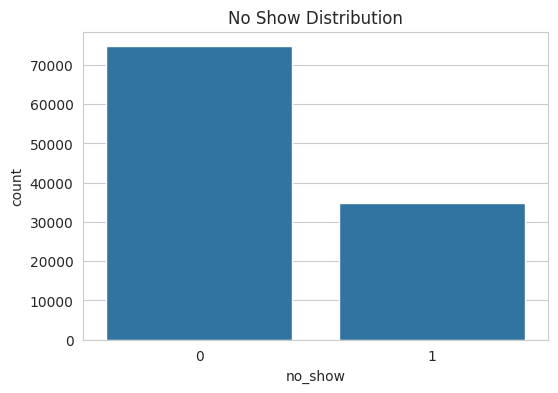

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='no_show', data=df)

plt.title("No Show Distribution")
plt.show()

In [18]:
df['no_show'].value_counts(normalize=True)*100

,proportion
no_show,
0,68.216948
1,31.783052


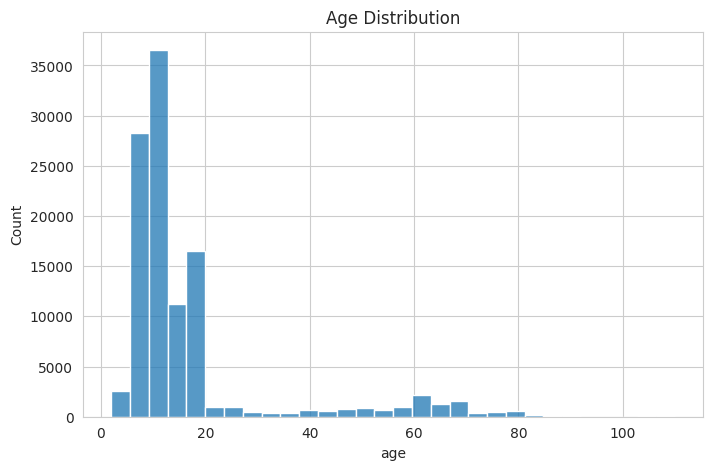

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30)

plt.title("Age Distribution")
plt.show()

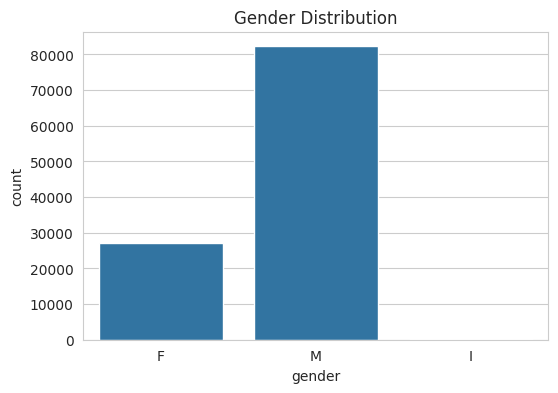

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.show()

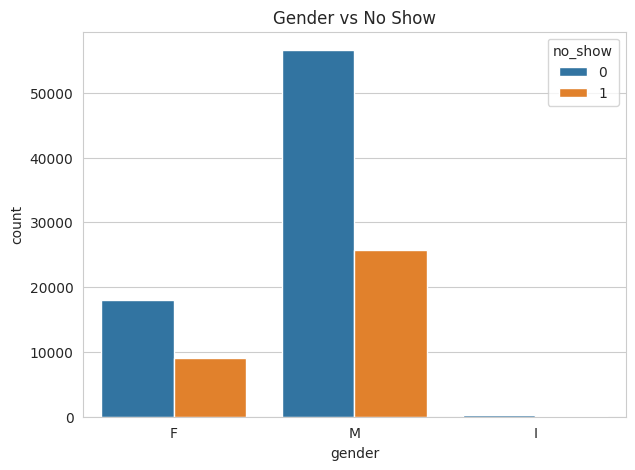

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='gender',
    hue='no_show',
    data=df
)

plt.title("Gender vs No Show")
plt.show()

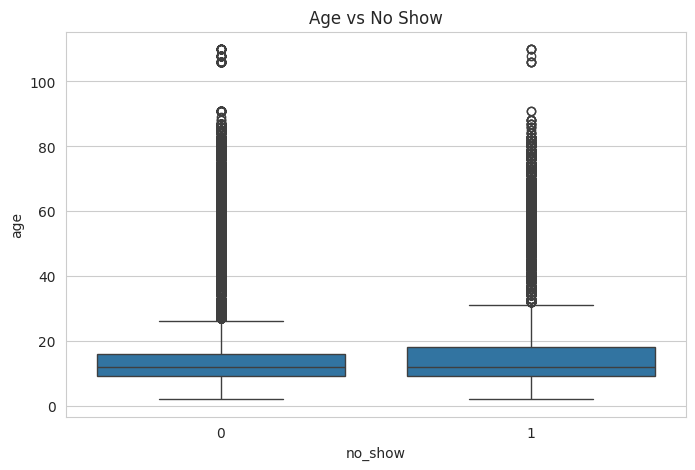

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='no_show',
    y='age',
    data=df
)

plt.title("Age vs No Show")
plt.show()

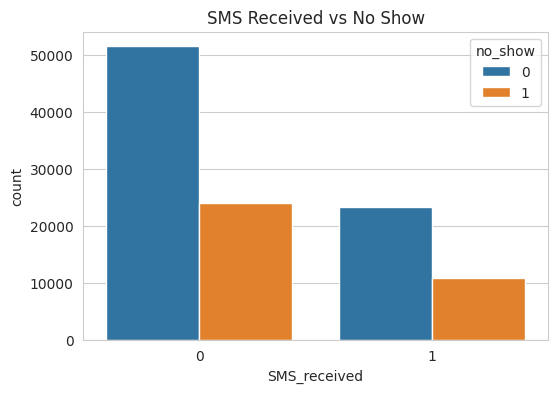

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='SMS_received',
    hue='no_show',
    data=df
)

plt.title("SMS Received vs No Show")
plt.show()

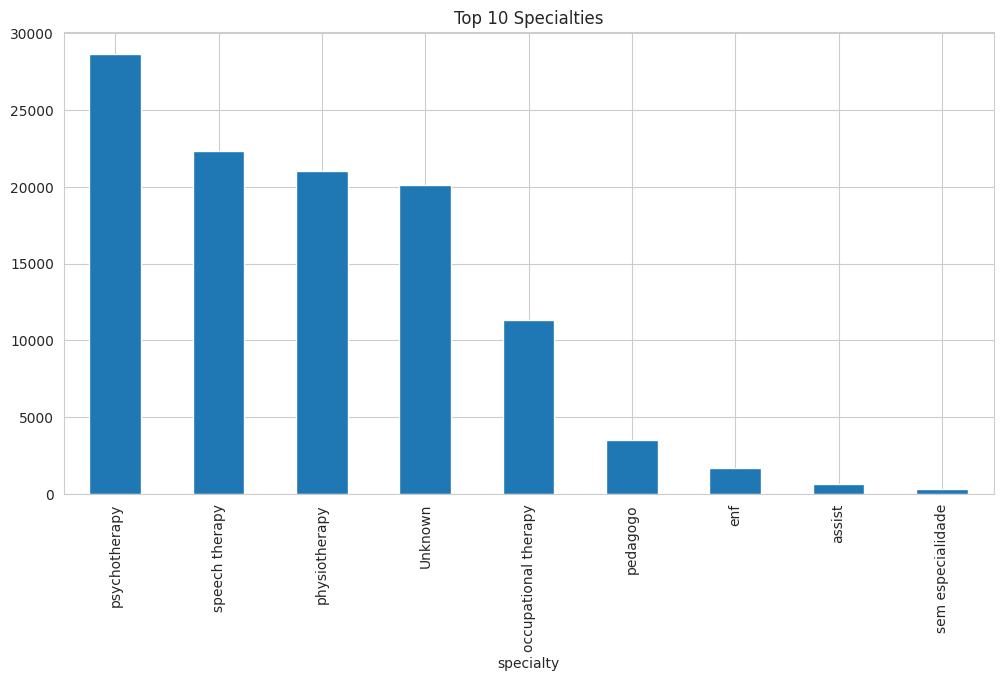

In [24]:
plt.figure(figsize=(12,6))

df['specialty'].value_counts()[:10].plot(
    kind='bar'
)

plt.title("Top 10 Specialties")
plt.show()

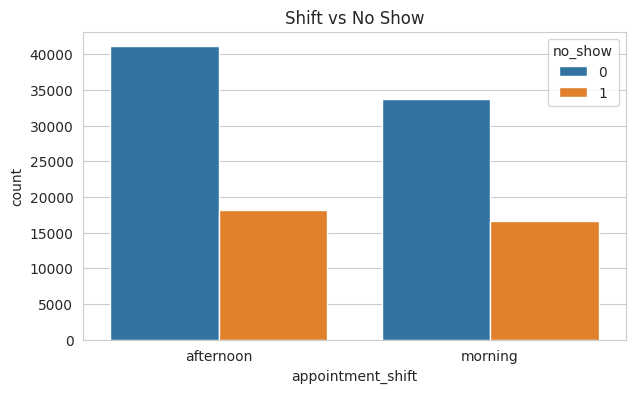

In [25]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='appointment_shift',
    hue='no_show',
    data=df
)

plt.title("Shift vs No Show")
plt.show()

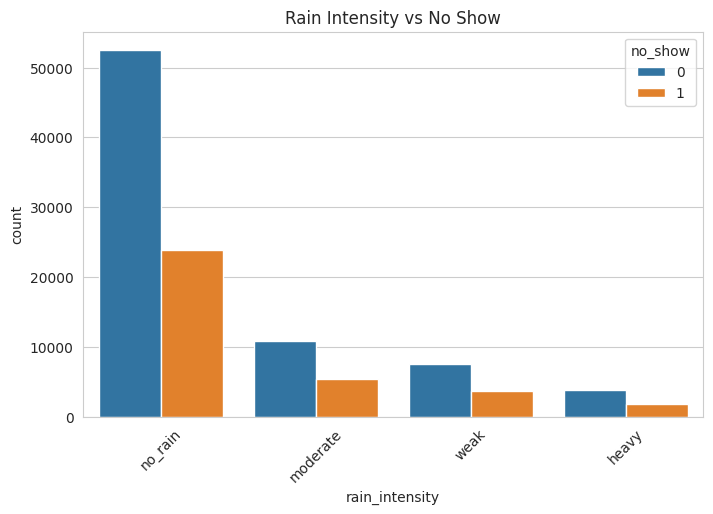

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='rain_intensity',
    hue='no_show',
    data=df
)

plt.xticks(rotation=45)

plt.title("Rain Intensity vs No Show")
plt.show()

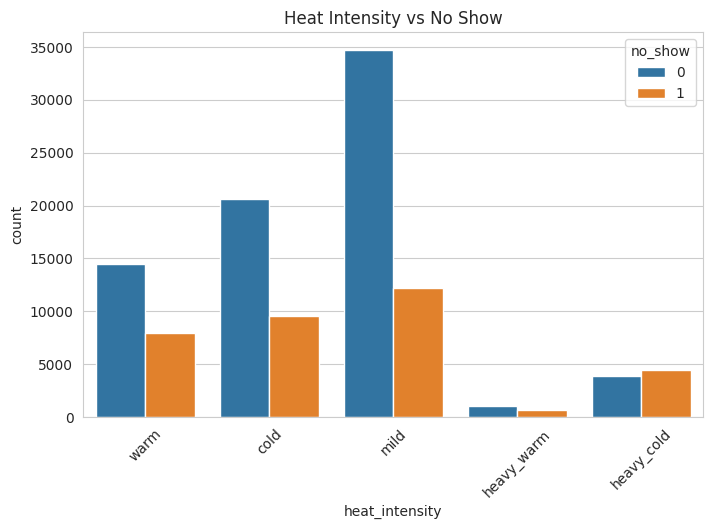

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='heat_intensity',
    hue='no_show',
    data=df
)

plt.xticks(rotation=45)

plt.title("Heat Intensity vs No Show")
plt.show()

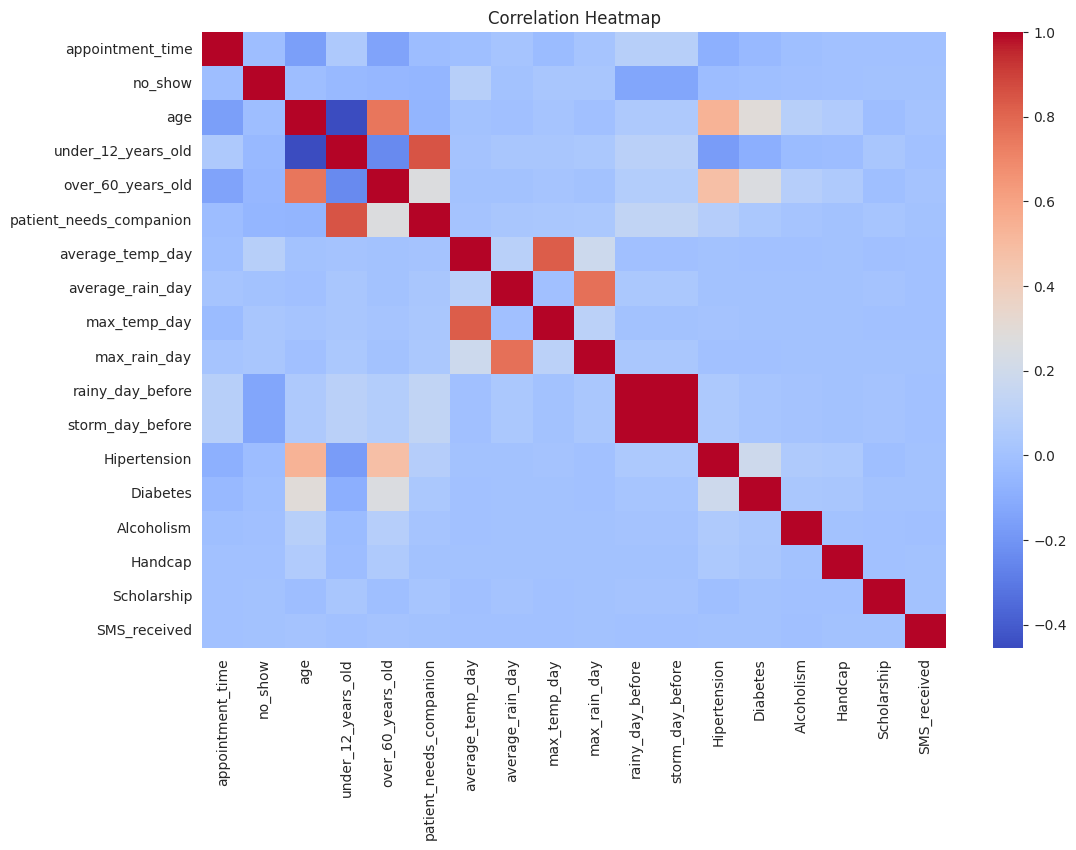

In [28]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(
    include=['int64','float64']
)

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

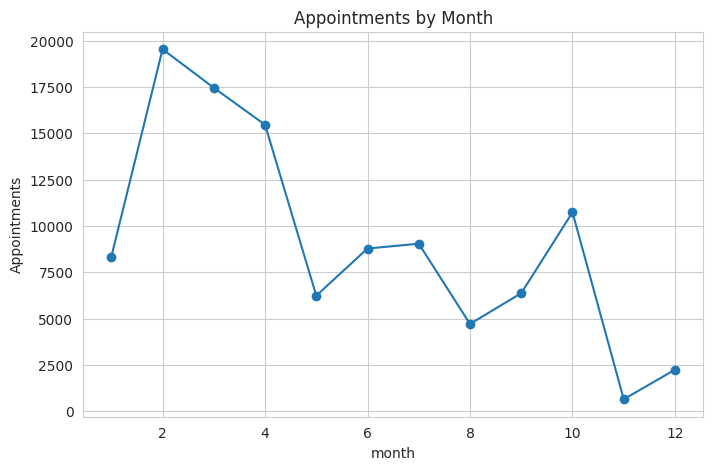

In [29]:
monthly = (
    df.groupby('month')
      .size()
)

monthly.plot(
    kind='line',
    marker='o',
    figsize=(8,5)
)

plt.title("Appointments by Month")
plt.ylabel("Appointments")
plt.show()

Observation:
Around 31.8% of appointments are missed.

Business Insight:
A high no-show rate can lead to wasted specialist
time and reduced clinic efficiency.

In [30]:
df_model = df.copy()

# Feature Engineering

In [31]:
df_model["month"] = df_model["appointment_date_continuous"].dt.month

df_model["day"] = df_model["appointment_date_continuous"].dt.day

df_model["weekday"] = df_model["appointment_date_continuous"].dt.dayofweek

In [32]:
df_model.drop(
    "appointment_date_continuous",
    axis=1,
    inplace=True
)

# training model

In [33]:
X = df_model.drop("no_show", axis=1)
y = df_model["no_show"]

In [34]:
y.value_counts()

,count
no_show,
0,74761
1,34832


In [35]:
X.select_dtypes(include="object").columns

Index(['specialty', 'gender', 'disability', 'place', 'appointment_shift',
       'rain_intensity', 'heat_intensity'],
      dtype='object')

In [36]:
cat_cols = [
    'specialty',
    'gender',
    'disability',
    'place',
    'appointment_shift',
    'rain_intensity',
    'heat_intensity'
]

In [37]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

In [38]:
df_model.shape

(109593, 30)

In [39]:
X = df_model.drop("no_show", axis=1)
y = df_model["no_show"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
print(X_train.shape)
print(X_test.shape)

(87674, 29)
(21919, 29)


# For No-Show Prediction (Classification):


# 1.Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [43]:
y_pred = lr.predict(X_test)

y_prob = lr.predict_proba(X_test)[:,1]
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score
)
print(classification_report(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.78      0.66      0.71     14952
           1       0.45      0.60      0.51      6967

    accuracy                           0.64     21919
   macro avg       0.61      0.63      0.61     21919
weighted avg       0.67      0.64      0.65     21919

F1 Score: 0.5139740132385389
ROC AUC: 0.6619215219144783


# 2.Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [45]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [46]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score

print(classification_report(y_test, rf_pred))

print("F1:", f1_score(y_test, rf_pred))
print("ROC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.85      0.69      0.76     14952
           1       0.52      0.73      0.61      6967

    accuracy                           0.70     21919
   macro avg       0.68      0.71      0.68     21919
weighted avg       0.74      0.70      0.71     21919

F1: 0.6100783071313288
ROC: 0.7716177390346587


# 3.xgboost

In [47]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2.15,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [48]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:, 1]

In [49]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score
)

print(classification_report(y_test, xgb_pred))

print("F1:", f1_score(y_test, xgb_pred))
print("ROC:", roc_auc_score(y_test, xgb_prob))

              precision    recall  f1-score   support

           0       0.88      0.65      0.75     14952
           1       0.52      0.81      0.63      6967

    accuracy                           0.70     21919
   macro avg       0.70      0.73      0.69     21919
weighted avg       0.77      0.70      0.71     21919

F1: 0.6343237647585473
ROC: 0.7849877706359024


XGBoost was selected as the final model because it achieved the highest ROC-AUC (0.783) and highest F1-score (0.629), demonstrating better discrimination between no-show and attended appointments.

In [50]:
# import joblib

#joblib.dump(
#    xgb,
#    "no_show_xgb_model.pkl"
#)

In [51]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
4,place,0.207706
15,storm_day_before,0.151099
8,over_60_years_old,0.079646
14,rainy_day_before,0.054282
3,disability,0.053588
6,age,0.036161
17,heat_intensity,0.034863
10,average_temp_day,0.026121
0,specialty,0.025014
13,max_rain_day,0.024223


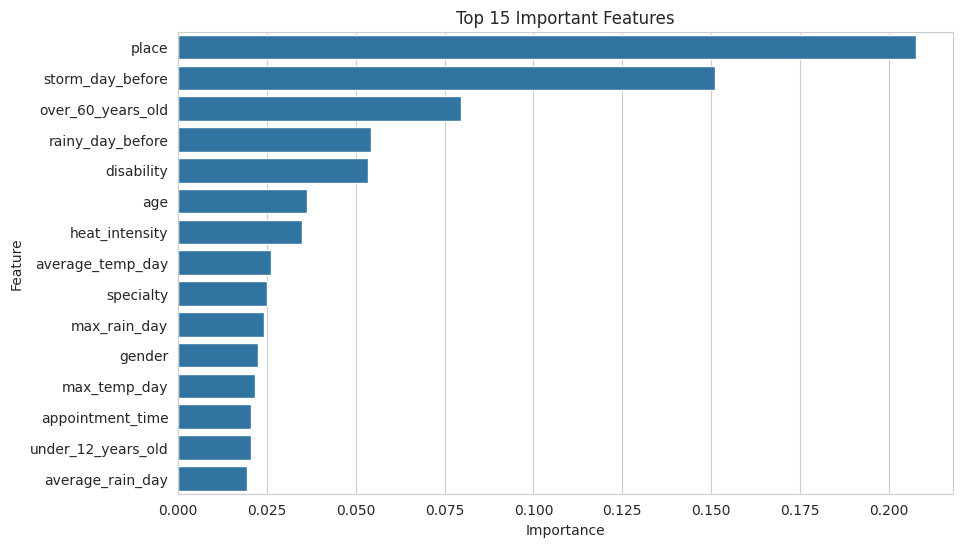

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

# For Demand Forecasting (Regression)

### Step 1 — Rebuild a clean copy for forecasting

We use `df` (already cleaned + date-parsed earlier) so this section doesn't depend
on the classification-only changes made to `df_model`.

In [ ]:
df_forecast = df.copy()

df_forecast["appointment_date_continuous"] = pd.to_datetime(
    df_forecast["appointment_date_continuous"]
)

print(df_forecast["appointment_date_continuous"].min(), "to",
      df_forecast["appointment_date_continuous"].max())
print(df_forecast.shape)


### Step 2 — Look at daily demand before modeling

The daily appointment count is very volatile (ranges from ~1 to ~1500 per day),
so it's worth seeing the trend before jumping into features.

In [ ]:
daily_volume = df_forecast.groupby(
    "appointment_date_continuous"
).size()

plt.figure(figsize=(14, 5))
daily_volume.plot()
plt.title("Daily Appointment Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Appointments")
plt.show()

print(daily_volume.describe())


### Step 3 — Aggregate to a daily table

One row per calendar day: appointment count (the forecasting target) plus
same-day averages for a few signals that plausibly move demand (SMS reminders,
patient age mix, chronic conditions, weather).

In [ ]:
daily = df_forecast.groupby("appointment_date_continuous").agg(
    appointment_count=("no_show", "count"),
    sms_received_rate=("SMS_received", "mean"),
    avg_age=("age", "mean"),
    hypertension_rate=("Hipertension", "mean"),
    diabetes_rate=("Diabetes", "mean"),
    avg_temp=("average_temp_day", "mean"),
    avg_rain=("average_rain_day", "mean"),
).reset_index()

daily = daily.sort_values("appointment_date_continuous").reset_index(drop=True)

print(daily.shape)
daily.head()


### Step 4 — Calendar features

Day-of-week and month matter a lot for appointment demand (weekday vs weekend,
seasonal patterns).

In [ ]:
daily["dayofweek"] = daily["appointment_date_continuous"].dt.dayofweek
daily["month"] = daily["appointment_date_continuous"].dt.month
daily["quarter"] = daily["appointment_date_continuous"].dt.quarter
daily["day"] = daily["appointment_date_continuous"].dt.day
daily["is_weekend"] = daily["dayofweek"].isin([5, 6]).astype(int)

daily.head()


### Step 5 — Lag & rolling features

These give the model "memory" of recent demand — usually the strongest predictors
in short-term demand forecasting. `shift(1)` before the rolling mean makes sure
we never use today's own count to predict today (no data leakage).

In [ ]:
daily["lag_1"] = daily["appointment_count"].shift(1)
daily["lag_7"] = daily["appointment_count"].shift(7)
daily["lag_14"] = daily["appointment_count"].shift(14)

daily["rolling_mean_7"] = daily["appointment_count"].shift(1).rolling(7).mean()
daily["rolling_mean_14"] = daily["appointment_count"].shift(1).rolling(14).mean()

# first 14 rows won't have full lag/rolling history yet
daily_model = daily.dropna().reset_index(drop=True)

print(daily_model.shape)
daily_model.head()


### Step 6 — Define features (X) and target (y)

In [ ]:
forecast_features = [
    "dayofweek", "month", "quarter", "day", "is_weekend",
    "sms_received_rate", "avg_age", "hypertension_rate", "diabetes_rate",
    "avg_temp", "avg_rain",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_mean_14"
]

X = daily_model[forecast_features]
y = daily_model["appointment_count"]

print(X.shape, y.shape)


### Step 7 — Chronological train/test split

**No shuffling** for time series — the test set must be the most recent days,
otherwise the model could "see the future" during training.

In [ ]:
split_idx = int(len(daily_model) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

train_dates = daily_model["appointment_date_continuous"].iloc[:split_idx]
test_dates = daily_model["appointment_date_continuous"].iloc[split_idx:]

print("Train:", X_train.shape, train_dates.min(), "->", train_dates.max())
print("Test: ", X_test.shape, test_dates.min(), "->", test_dates.max())


## Model Training — Demand Forecasting

### 1. Linear Regression (baseline)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

lin_pred = lin_reg.predict(X_test)

lin_mae = mean_absolute_error(y_test, lin_pred)
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_pred))
lin_r2 = r2_score(y_test, lin_pred)

print("MAE:", round(lin_mae, 2))
print("RMSE:", round(lin_rmse, 2))
print("R2:", round(lin_r2, 3))


### 2. Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)

rf_pred = rf_reg.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2:", round(rf_r2, 3))


### 3. XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train)

xgb_pred = xgb_reg.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("MAE:", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R2:", round(xgb_r2, 3))


### Step 8 — Compare models and pick the best one

In [ ]:
forecast_results = pd.DataFrame({
    "Linear Regression": [lin_mae, lin_rmse, lin_r2],
    "Random Forest": [rf_mae, rf_rmse, rf_r2],
    "XGBoost": [xgb_mae, xgb_rmse, xgb_r2],
}, index=["MAE", "RMSE", "R2"]).T.sort_values("R2", ascending=False)

forecast_results


In [ ]:
fitted_forecast_models = {
    "Linear Regression": lin_reg,
    "Random Forest": rf_reg,
    "XGBoost": xgb_reg
}

best_model_name = forecast_results.index[0]
best_model = fitted_forecast_models[best_model_name]

print("Best forecasting model:", best_model_name)
print(forecast_results.loc[best_model_name])


### Step 9 — Actual vs Predicted (best model, test period)

In [ ]:
best_pred = best_model.predict(X_test)

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test.values, label="Actual", marker="o", markersize=3)
plt.plot(test_dates, best_pred, label="Predicted", marker="x", markersize=3)
plt.title(f"Actual vs Predicted Daily Appointments - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Appointment Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Step 10 — Feature importance (best model, if tree-based)

In [ ]:
if hasattr(best_model, "feature_importances_"):
    forecast_importance = pd.DataFrame({
        "Feature": forecast_features,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=forecast_importance, x="Importance", y="Feature")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} has no feature_importances_ (e.g. Linear Regression uses coefficients).")


### Observation

Daily appointment volume swings from about 1 to 1,500+ per day, and the most
recent weeks in the data drop to very low single-digit counts. Because MAPE
divides by the actual value, low-volume days inflate that metric even when the
absolute error is small — so MAE, RMSE, and R² are the more reliable metrics
here, and lag/rolling features tend to dominate feature importance since
recent demand is the strongest predictor of near-term demand.

### Step 11 — Save the best model

In [ ]:
import joblib

joblib.dump(best_model, "demand_forecasting_model.pkl")
joblib.dump(forecast_features, "forecast_features.pkl")

print("Saved demand_forecasting_model.pkl (", best_model_name, ") and forecast_features.pkl")


In [ ]:
# Uncomment to download from Colab
# from google.colab import files
# files.download("demand_forecasting_model.pkl")
# files.download("forecast_features.pkl")
